# Support Vector Machines

A Support Vector Machine (SVM) is a classification algorithm that works by finding the best possible boundary between two classes of data. What makes SVMs special is *how* they define "best": they look for the boundary that **maximizes the margin** — the gap between the boundary line and the nearest data points from each class.

The intuition is that a boundary that sits right up against the data is fragile. A small change in a data point could flip its classification. A boundary with a wide, clear margin is more robust — it has room to breathe and will likely generalize better to new data.

**What support vectors are:** The data points closest to the boundary — the ones that define the margin — are called support vectors. They are the only points that actually determine where the boundary goes. You could remove all the other training examples and the boundary would not move. This dependence on a small subset of the data is both a strength (computationally efficient) and something to be aware of (outliers near the boundary can have a large influence).

This notebook works through three increasingly powerful versions of the idea:
1. A hard-margin classifier (works only when the data is perfectly separable)
2. A soft-margin classifier (allows some errors for better generalization)
3. A full SVM with kernel tricks (handles non-linear boundaries)

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

## The Support Vector Classifier (Soft Margin)

In a perfect world, the two classes would be cleanly separable, and we could find a boundary with zero errors. In practice, data is messy. Classes overlap, there are outliers, and a boundary that insists on zero training errors will be very sensitive to individual data points — a form of overfitting.

The **support vector classifier** (also called a soft-margin classifier) relaxes the requirement. It allows some training points to be on the wrong side of the margin or even the wrong side of the boundary entirely. This is controlled by the **C parameter**:

- **Large C in scikit-learn** means we heavily penalize misclassifications — the model tries hard to classify every training point correctly. This narrows the margin and can overfit.
- **Small C** means we tolerate more errors in exchange for a wider, more stable margin. More training points get misclassified, but the boundary generalizes better to new data.

Note: scikit-learn's C works in the *opposite* direction from the textbook's budget parameter. In scikit-learn, larger C = stricter = narrower margin. The code cell below clarifies this.

The plot function marks support vectors (the points closest to the boundary) with vertical bars. Pay attention to how the number of support vectors changes as C changes.

In [3]:
def plot_svc(svc, X, y, h=0.02, pad=0.25):
    x_min, x_max = X[:, 0].min()-pad, X[:, 0].max()+pad
    y_min, y_max = X[:, 1].min()-pad, X[:, 1].max()+pad
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.2)

    plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=plt.cm.Paired)
    # Support vectors indicated in plot by vertical lines
    sv = svc.support_vectors_
    plt.scatter(sv[:,0], sv[:,1], c='k', marker='|', s=100, linewidths=1)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.show()
    print('Number of support vectors: ', svc.support_.size)

Text(0.5, 0, 'X1')

Text(0, 0.5, 'X2')

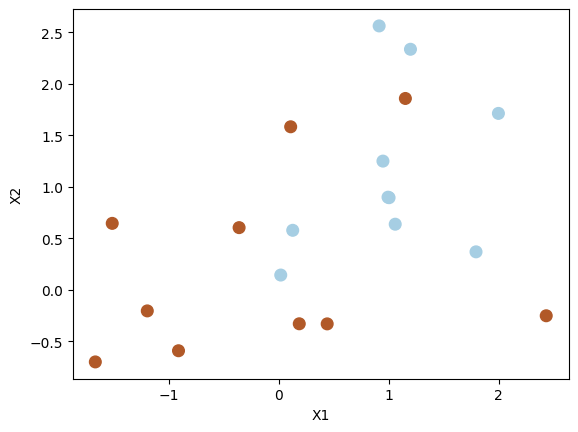

In [4]:
# Generating random data: 20 observations of 2 features and divide into two classes.
np.random.seed(5)
X = np.random.randn(20,2)
y = np.repeat([1,-1], 10)

X[y == -1] = X[y == -1] +1
plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=plt.cm.Paired)
plt.xlabel('X1')
plt.ylabel('X2')

plt.show()

**The C parameter in practice:** The two cells below show the same data with different values of C. With `C=1.0`, the margin is tighter and the boundary fits the training data closely. With `C=0.1`, the margin is wider and more training points fall inside it — but the boundary is smoother and less sensitive to individual points. Notice how the number of support vectors (marked with bars) increases as C decreases.

**A note on how scikit-learn's C works:** In scikit-learn, C is the penalty coefficient on misclassifications — a larger C means the model is penalized more for errors and will try harder to classify everything correctly (narrower margin). This is the **opposite** of how some textbooks define C as an error budget (where larger C allows more errors). When reading outside documentation, double-check which convention is being used. See: https://scikit-learn.org/stable/modules/svm.html#svc

SVC(kernel='linear')

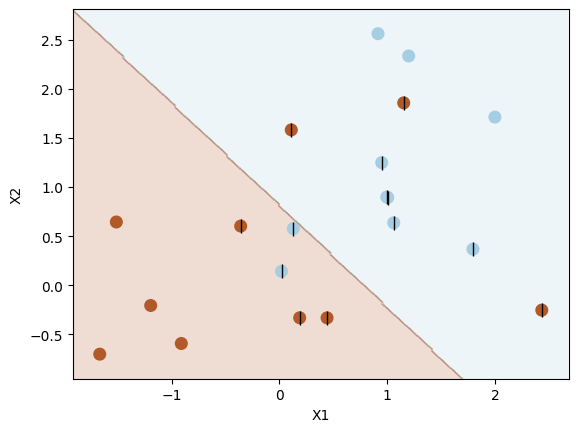

Number of support vectors:  13


In [5]:
# Support Vector Classifier with linear kernel.
svc = SVC(C= 1.0, kernel='linear')
svc.fit(X, y)

plot_svc(svc, X, y)

SVC(C=0.1, kernel='linear')

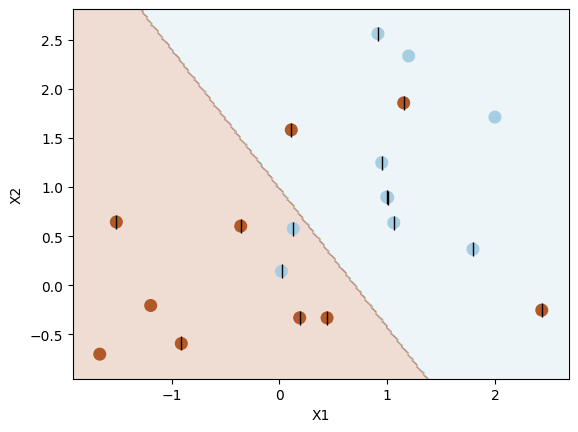

Number of support vectors:  16


In [6]:
# When using a smaller cost parameter (C=0.1) the margin is wider, resulting in more support vectors.
svc2 = SVC(C=0.1, kernel='linear')
svc2.fit(X, y)
plot_svc(svc2, X, y)

**Finding the best C with cross-validation:** Rather than guessing, we can systematically try many values of C and use cross-validation to pick the one that performs best on held-out data. The cell below does this using `GridSearchCV`, which tries each candidate C value across multiple train/test splits and reports which one had the highest average accuracy.

In [7]:
# Select the optimal C parameter by cross-validation
tuned_parameters = [{'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}]
clf = GridSearchCV(SVC(kernel='linear'), tuned_parameters, cv=10, scoring='accuracy', return_train_score=True)
clf.fit(X, y)
print('\n')
clf.cv_results_

GridSearchCV(cv=10, estimator=SVC(kernel='linear'),
             param_grid=[{'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}],
             return_train_score=True, scoring='accuracy')

{'mean_fit_time': array([0.00031445, 0.00027277, 0.00026178, 0.00027649, 0.00026999,
        0.00028698, 0.00034401]),
 'std_fit_time': array([8.08114806e-05, 1.90225906e-05, 2.01460172e-06, 2.67898153e-05,
        4.78526936e-06, 1.00192837e-05, 2.33695089e-05]),
 'mean_score_time': array([0.00028455, 0.00025678, 0.00025105, 0.00026052, 0.00025139,
        0.00026226, 0.00024927]),
 'std_score_time': array([7.40592161e-05, 1.19047055e-05, 3.58263087e-06, 2.37089386e-05,
        1.23818001e-05, 2.24518916e-05, 1.85981774e-06]),
 'param_C': masked_array(data=[0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 100.0],
              mask=[False, False, False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'C': 0.001},
  {'C': 0.01},
  {'C': 0.1},
  {'C': 1},
  {'C': 5},
  {'C': 10},
  {'C': 100}],
 'split0_test_score': array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]),
 'split1_test_score': array([0.5, 0.5, 0.5, 0. , 0. , 0. , 0. ]),
 'split2_test_score': array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5

In [8]:
# 0.001 is best according to GridSearchCV.
clf.best_params_

{'C': 0.001}

**Interactive C explorer:** Use the slider below to see how different values of C affect the linear SVC on this dataset. Watch the number of support vectors reported — it tells you how tight or loose the margin is.

In [9]:
import ipywidgets as widgets
from IPython.display import display

def fit_linear_svc(log_C):
    C_val = 10 ** log_C
    svc_w = SVC(C=C_val, kernel='linear')
    svc_w.fit(X, y)
    print(f"C = {C_val:.4f} (10^{log_C})")
    plot_svc(svc_w, X, y)

widgets.interact(
    fit_linear_svc,
    log_C=widgets.FloatSlider(value=0, min=-3, max=2, step=0.5,
                              description="log10(C):",
                              readout_format='.1f')
);

interactive(children=(FloatSlider(value=0.0, description='log10(C):', max=2.0, min=-3.0, readout_format='.1f',…

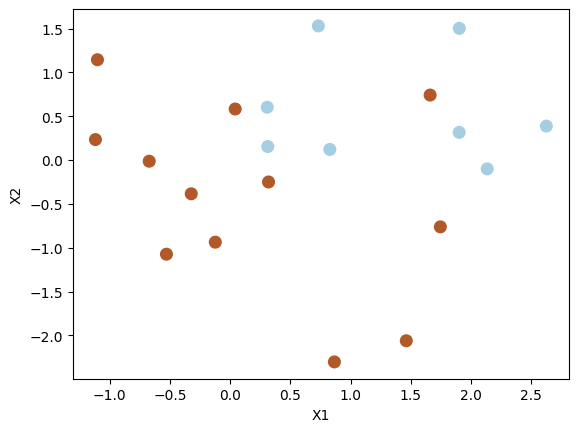

In [10]:
# Generating test data
np.random.seed(1)
X_test = np.random.randn(20,2)
y_test = np.random.choice([-1,1], 20)
X_test[y_test == -1] = X_test[y_test == -1] +1

plt.scatter(X_test[:,0], X_test[:,1], s=70, c=y_test, cmap=plt.cm.Paired)
plt.xlabel('X1')
plt.ylabel('X2');

In [11]:
# svc2 : C = 0.1
y_pred = svc2.predict(X_test)
pd.DataFrame(confusion_matrix(y_test, y_pred),index=svc.classes_, columns=svc.classes_)

,-1,1
-1,7,1
1,2,10


In [12]:
svc3 = SVC(C=0.001, kernel='linear')
svc3.fit(X, y)

# svc3 : C = 0.001
y_pred = svc3.predict(X_test)
pd.DataFrame(confusion_matrix(y_test, y_pred), index=svc3.classes_, columns=svc3.classes_)
# The misclassification is the same

SVC(C=0.001, kernel='linear')

,-1,1
-1,7,1
1,2,10


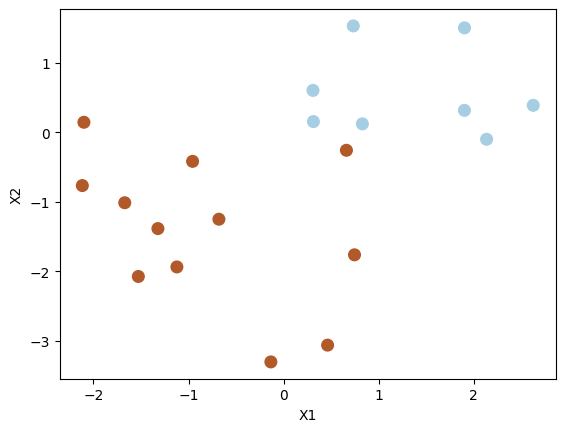

In [13]:
# Changing the test data so that the classes are really seperable with a hyperplane.
X_test[y_test == 1] = X_test[y_test == 1] -1
plt.scatter(X_test[:,0], X_test[:,1], s=70, c=y_test, cmap=plt.cm.Paired)
plt.xlabel('X1')
plt.ylabel('X2');

SVC(C=10.0, kernel='linear')

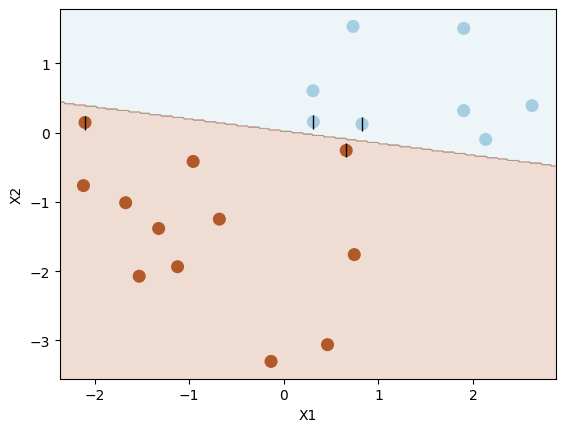

Number of support vectors:  4


In [14]:
svc4 = SVC(C=10.0, kernel='linear')
svc4.fit(X_test, y_test)
plot_svc(svc4, X_test, y_test)

SVC(C=1, kernel='linear')

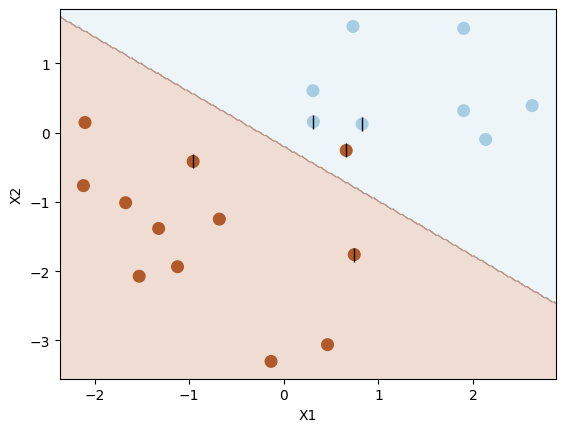

Number of support vectors:  5


In [15]:
# Increase the margin. Now there is one misclassification: increased bias, lower variance.
svc5 = SVC(C=1, kernel='linear')
svc5.fit(X_test, y_test)
plot_svc(svc5, X_test, y_test)

## Support Vector Machines — Handling Non-Linear Boundaries

The soft-margin classifier works well when the boundary between classes is roughly linear. But what if the classes are arranged in a circle, or in an interleaved pattern where no straight line could ever separate them?

**The kernel trick:** SVMs can handle non-linear boundaries by implicitly mapping the data into a higher-dimensional space where a linear boundary *does* work. Here's the key insight: we never actually have to compute the coordinates in that higher-dimensional space. We only need to compute how similar any two data points are to each other, which we do with a function called a **kernel**.

Think of it this way: imagine the data is arranged in two circles (one class inside, one outside). In 2D, no line separates them. But if you could lift the inner circle up into 3D, a flat plane could cleanly separate the two classes. The kernel trick does the equivalent of this lifting — without ever explicitly building the higher-dimensional coordinates.

**Common kernels:**
- **Linear**: just the original features — equivalent to the soft-margin classifier above
- **Polynomial**: considers combinations of features up to a given degree (e.g., interactions between features)
- **RBF (Radial Basis Function)**: the most popular choice. It measures similarity based on distance. Points close together in the original space are treated as similar; points far apart are treated as different. This allows very flexible, curved boundaries.

**The gamma parameter in RBF:** Gamma controls how far the "influence" of a single training point reaches.
- **Small gamma**: each training point influences a wide area — the boundary is smooth and may underfit
- **Large gamma**: each training point only influences nearby points — the boundary becomes very wiggly and may overfit

In practice, you tune both C and gamma together using cross-validation.

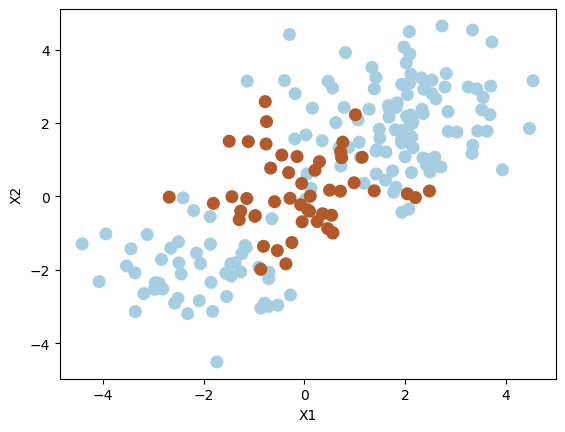

In [16]:
# Generating test data
np.random.seed(8)
X = np.random.randn(200,2)
X[:100] = X[:100] +2
X[101:150] = X[101:150] -2
y = np.concatenate([np.repeat(-1, 150), np.repeat(1,50)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=plt.cm.Paired)
plt.xlabel('X1')
plt.ylabel('X2');

SVC(gamma=1)

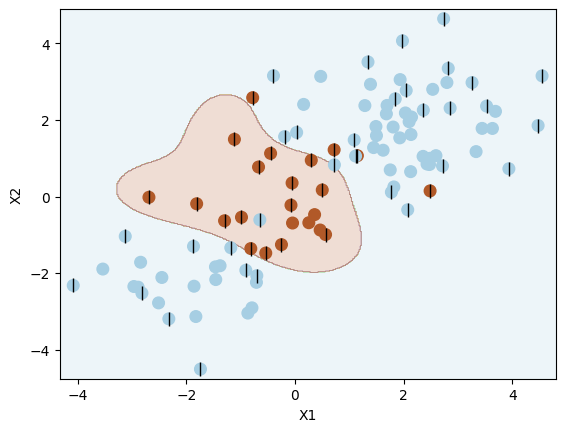

Number of support vectors:  51


In [17]:
svm = SVC(C=1.0, kernel='rbf', gamma=1)
svm.fit(X_train, y_train)
plot_svc(svm, X_train, y_train)

**Effect of C with an RBF kernel:** The two cells below compare `C=1` and `C=100` with the same RBF kernel and gamma. Higher C forces the model to fit the training data more closely, which produces a more jagged decision boundary. Lower C allows some training errors for a smoother, more generalizable boundary.

SVC(C=100, gamma=1)

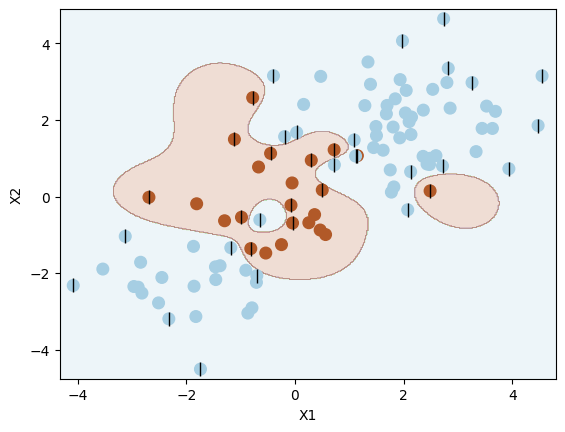

Number of support vectors:  36


In [18]:
# Increasing C parameter, allowing more flexibility
svm2 = SVC(C=100, kernel='rbf', gamma=1)
svm2.fit(X_train, y_train)
plot_svc(svm2, X_train, y_train)

**Tuning C and gamma together:** Just like we found the best C with cross-validation for the linear kernel, we can do the same for the RBF kernel — but now we need to tune *both* C and gamma at the same time. The grid search below tries all combinations of candidate C and gamma values across 10 cross-validation folds. The best combination is the one that generalizes best.

In [19]:
# Set the parameters by cross-validation
tuned_parameters = [{'C': [0.01, 0.1, 1, 10, 100],
                     'gamma': [0.5, 1,2,3,4]}]
clf = GridSearchCV(SVC(kernel='rbf'), tuned_parameters, cv=10, scoring='accuracy', return_train_score=True)
clf.fit(X_train, y_train)
print('\n')
clf.cv_results_

GridSearchCV(cv=10, estimator=SVC(),
             param_grid=[{'C': [0.01, 0.1, 1, 10, 100],
                          'gamma': [0.5, 1, 2, 3, 4]}],
             return_train_score=True, scoring='accuracy')

{'mean_fit_time': array([0.00033035, 0.00031791, 0.0003346 , 0.0003386 , 0.00033753,
        0.00031345, 0.0003278 , 0.00034616, 0.00036864, 0.00037644,
        0.0003176 , 0.000333  , 0.0003732 , 0.00038147, 0.00039756,
        0.00033107, 0.00033503, 0.00039558, 0.00039783, 0.00039895,
        0.00035062, 0.00034511, 0.00037761, 0.00038028, 0.0003793 ]),
 'std_fit_time': array([4.77415211e-05, 5.46722447e-06, 1.66173474e-05, 2.78409206e-06,
        2.17484273e-06, 2.65930249e-06, 5.01410767e-06, 5.40264076e-06,
        3.06802749e-05, 7.85512334e-06, 7.97220535e-06, 9.28918071e-06,
        1.39742781e-05, 5.89332919e-06, 2.46947446e-05, 1.34461315e-05,
        8.63048911e-06, 1.96213711e-05, 1.11151140e-05, 1.00192837e-05,
        1.27156476e-05, 1.82782481e-05, 1.88735978e-05, 9.09997212e-06,
        2.56435669e-05]),
 'mean_score_time': array([0.00026574, 0.00025859, 0.00026376, 0.0002655 , 0.00026364,
        0.00025823, 0.00025818, 0.00026219, 0.00026901, 0.00027437,
        0.00

In [20]:
clf.best_params_

{'C': 10, 'gamma': 0.5}

**Interactive SVM explorer:** Use the sliders and dropdown below to experiment with different kernel types, C values, and gamma values. Notice how the decision boundary changes shape, and how the number of support vectors responds to your choices.

In [21]:
import ipywidgets as widgets
from IPython.display import display

def fit_svm_interactive(kernel, log_C, log_gamma):
    C_val = 10 ** log_C
    gamma_val = 10 ** log_gamma
    params = {'C': C_val, 'kernel': kernel}
    if kernel in ('rbf', 'poly'):
        params['gamma'] = gamma_val
    svm_w = SVC(**params)
    svm_w.fit(X_train, y_train)
    acc = svm_w.score(X_test, y_test)
    print(f"Kernel: {kernel}, C: {C_val:.3f}, gamma: {gamma_val:.3f}")
    print(f"Test accuracy: {acc:.3f}")
    plot_svc(svm_w, X_train, y_train)

widgets.interact(
    fit_svm_interactive,
    kernel=widgets.Dropdown(options=['rbf', 'linear', 'poly'], value='rbf', description='Kernel:'),
    log_C=widgets.FloatSlider(value=1, min=-2, max=3, step=0.5, description='log10(C):'),
    log_gamma=widgets.FloatSlider(value=0, min=-2, max=2, step=0.5, description='log10(gamma):')
);

interactive(children=(Dropdown(description='Kernel:', options=('rbf', 'linear', 'poly'), value='rbf'), FloatSl…

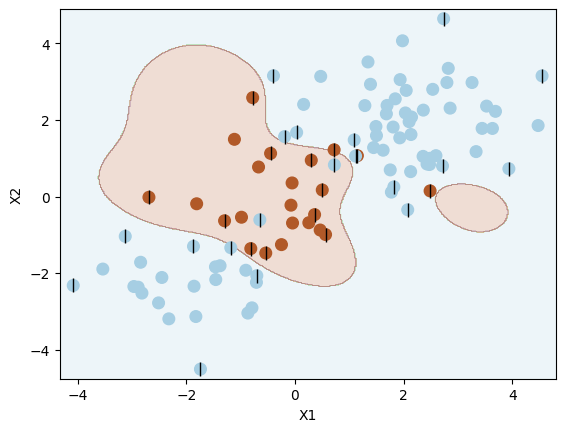

Number of support vectors:  32


In [22]:
plot_svc(clf.best_estimator_, X_train, y_train)

**Reading the results:** The cells below show the best model's decision boundary, the confusion matrix on the test set, and the overall test accuracy. The confusion matrix shows how many of each class were correctly classified versus misclassified. With SVMs, a 13% error rate on this synthetic dataset is reasonable — the classes genuinely overlap in the original feature space.

In [23]:
confusion_matrix(y_test, clf.best_estimator_.predict(X_test))

array([[66,  7],
       [ 6, 21]])

In [24]:
# 13% of test observations misclassified
clf.best_estimator_.score(X_test, y_test)

0.87

## SVMs with Multiple Classes

So far we have only handled binary classification. SVMs extend to K > 2 classes through two strategies.

**One-vs-One (OvO):** Train one SVM for every pair of classes — C(K, 2) classifiers total. To classify a new point, each classifier votes, and the class that wins the most pairwise votes is the final prediction. Scikit-learn uses OvO by default for SVC.

**One-vs-All (OvA):** Train K classifiers, each separating one class from all the rest. Predict the class whose classifier returns the highest decision-function score. Use `LinearSVC` or `SVC` with `decision_function_shape='ovr'` for this approach.

OvO tends to produce slightly better accuracy (each classifier handles a simpler binary problem), but OvA scales better when K is large (K classifiers vs K*(K-1)/2).

In [25]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

Scikit-learn's `SVC` automatically uses one-vs-one when there are more than two classes.

In [26]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ovo_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovo'))
])
ovo_svm.fit(X_tr, y_tr)
print('One-vs-One SVM')
print(classification_report(y_te, ovo_svm.predict(X_te), target_names=iris.target_names))

Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(decision_function_shape='ovo'))])

One-vs-One SVM
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



For comparison, here is the one-vs-all (OvR) variant using `decision_function_shape='ovr'`:

In [27]:
ovr_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovr'))
])
ovr_svm.fit(X_tr, y_tr)
print('One-vs-All SVM')
print(classification_report(y_te, ovr_svm.predict(X_te), target_names=iris.target_names))

Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC())])

One-vs-All SVM
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



**Interactive multiclass explorer:** Try different kernels and C values on the three-class Iris problem.

In [28]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# Use first two features so we can plot the decision boundary
X2 = X_iris[:, :2]
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y_iris, test_size=0.3, random_state=42)

def plot_multiclass_svm(kernel, log_C):
    C_val = 10 ** log_C
    scaler = StandardScaler()
    X2_tr_s = scaler.fit_transform(X2_tr)
    X2_te_s = scaler.transform(X2_te)
    clf = SVC(kernel=kernel, C=C_val, gamma='scale')
    clf.fit(X2_tr_s, y2_tr)
    acc = clf.score(X2_te_s, y2_te)

    h = 0.02
    x_min, x_max = X2_tr_s[:, 0].min() - 0.5, X2_tr_s[:, 0].max() + 0.5
    y_min, y_max = X2_tr_s[:, 1].min() - 0.5, X2_tr_s[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
    colors = ['#e41a1c', '#377eb8', '#4daf4a']
    for cls, col, name in zip([0, 1, 2], colors, iris.target_names):
        ax.scatter(X2_tr_s[y2_tr==cls, 0], X2_tr_s[y2_tr==cls, 1],
                   c=col, label=name, edgecolors='k', s=40)
    ax.set_title(f'kernel={kernel}, C={C_val:.2f} | test acc={acc:.2f}')
    ax.set_xlabel('sepal length (scaled)')
    ax.set_ylabel('sepal width (scaled)')
    ax.legend()
    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_multiclass_svm,
    kernel=widgets.Dropdown(options=['linear', 'rbf', 'poly'], value='rbf', description='Kernel'),
    log_C=widgets.FloatSlider(value=0, min=-2, max=2, step=0.5, description='log10(C)',
                              style={'description_width': 'initial'})
);

interactive(children=(Dropdown(description='Kernel', index=1, options=('linear', 'rbf', 'poly'), value='rbf'),…